# Sincronización de Series Temporales: FormacionNIRHumedadPV vs Etapa2MWHumedadPV

Análisis de sincronización entre dos mediciones de humedad:
- **FormacionNIRHumedadPV**: Humedad medida por NIR en formación
- **Etapa2MWHumedadPV**: Humedad medida en Etapa 2 MW

Datos: `data/datos_peso_01_11_2021_07_11_2021.pqt` (1-7 Nov 2021)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

DATA_PATH = Path('../data/datos_peso_01_11_2021_07_11_2021.pqt')

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Date range: {df.index.min()} to {df.index.max()}')
print(f'Duplicate timestamps: {df.index.duplicated().sum()}')
print(f'Null values:\n{df.isnull().sum()}')

Shape: (447675, 23)
Columns: ['DiscosVida', 'DiscosDistancia', 'SiloFibraVelocidadPV', 'SiloRechazosVelocidadPV', 'FormadoraVelocidadPV', 'ScalperPosPV', 'ScalperReservaMediaPV', 'FormacionVelocidad', 'ColaSecaMaderaSecaPV', 'ParafinaSecaMaderaSecaPV', 'FincatSecaMaderaSecaPV', 'IgnifuganteSecaMaderaSecaPV', 'Etapa2MWHumedadPV', 'Etapa2MWHumedadSP', 'FormacionNIRHumedadPV', 'FormacionNIRResina', 'PreprensaEntPosPV', 'PreprensaEntPresionPV', 'PreprensaSalPosPV', 'PreprensaSalPresionPV', 'PreprensaPrecompresorPosPV', 'ComisionActualProductoCodigo', 'BasculaMantaPesoPV']
Date range: 2021-11-01 00:00:01.316000 to 2021-11-07 00:00:00.715000
Duplicate timestamps: 128845
Null values:
DiscosVida                      0
DiscosDistancia                 0
SiloFibraVelocidadPV            0
SiloRechazosVelocidadPV         0
FormadoraVelocidadPV            0
ScalperPosPV                    0
ScalperReservaMediaPV           0
FormacionVelocidad              0
ColaSecaMaderaSecaPV            0
Parafina

In [3]:
# Explore the two target series
target_cols = ['FormacionNIRHumedadPV', 'Etapa2MWHumedadPV']

for col in target_cols:
    print(f'=== {col} ===')
    print(f'  Count: {df[col].count():,}')
    print(f'  Nulls: {df[col].isna().sum():,}')
    print(f'  Min: {df[col].min():.4f}')
    print(f'  Max: {df[col].max():.4f}')
    print(f'  Mean: {df[col].mean():.4f}')
    print(f'  Std: {df[col].std():.4f}')
    print()

=== FormacionNIRHumedadPV ===
  Count: 447,675
  Nulls: 0
  Min: 6.0000
  Max: 11.4755
  Mean: 8.4996
  Std: 0.6636

=== Etapa2MWHumedadPV ===
  Count: 447,675
  Nulls: 0
  Min: 0.0000
  Max: 19.0827
  Mean: 12.5507
  Std: 1.2900



In [4]:
# Handle duplicate timestamps - keep first occurrence
df_clean = df[~df.index.duplicated(keep='first')].copy()
print(f'Original rows: {len(df):,}')
print(f'After dedup: {len(df_clean):,}')
print(f'Removed duplicates: {len(df) - len(df_clean):,}')

# Select only numeric columns for resampling
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print(f'Numeric columns: {len(numeric_cols)}')

# Resample to regular 1-second frequency
df_resampled = df_clean[numeric_cols].resample('1s').mean()
print(f'Resampled to 1s: {len(df_resampled):,} rows')
print(f'Date range: {df_resampled.index.min()} to {df_resampled.index.max()}')

Original rows: 447,675
After dedup: 318,830
Removed duplicates: 128,845
Numeric columns: 22


Resampled to 1s: 518,400 rows
Date range: 2021-11-01 00:00:01 to 2021-11-07 00:00:00


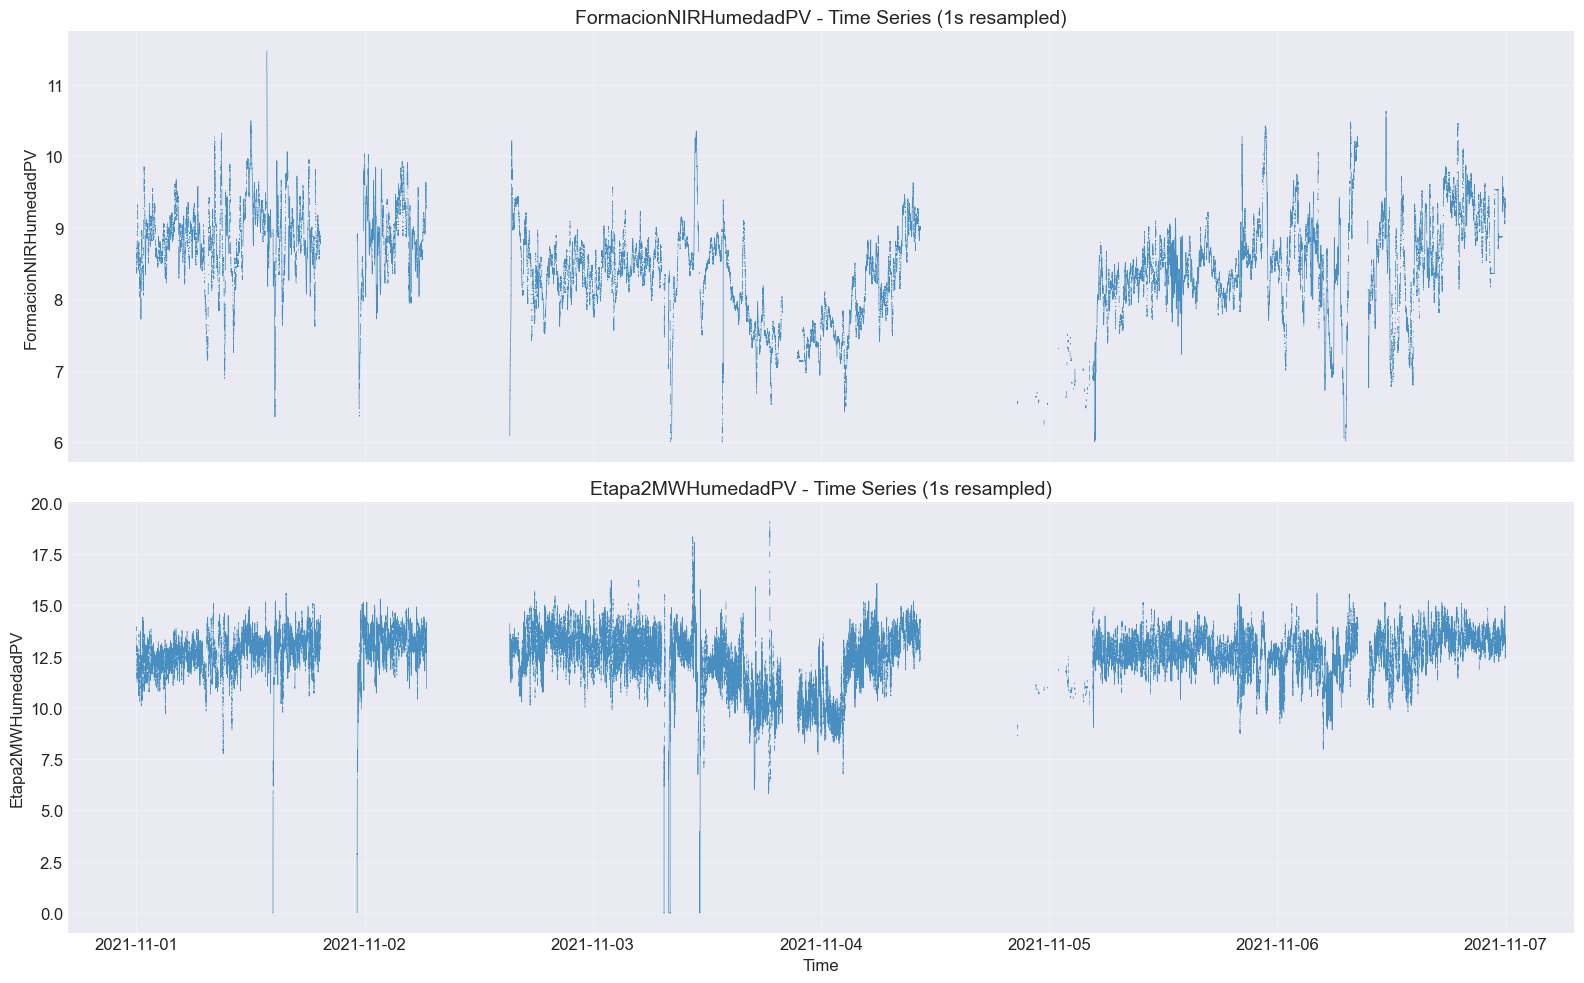

In [5]:
# Plot both time series
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for i, col in enumerate(target_cols):
    ax = axes[i]
    ax.plot(df_resampled.index, df_resampled[col], linewidth=0.5, alpha=0.8)
    ax.set_ylabel(col, fontsize=12)
    ax.set_title(f'{col} - Time Series (1s resampled)', fontsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time', fontsize=12)
plt.tight_layout()
plt.show()

Correlation matrix:
                       FormacionNIRHumedadPV  Etapa2MWHumedadPV
FormacionNIRHumedadPV               1.000000           0.392399
Etapa2MWHumedadPV                   0.392399           1.000000


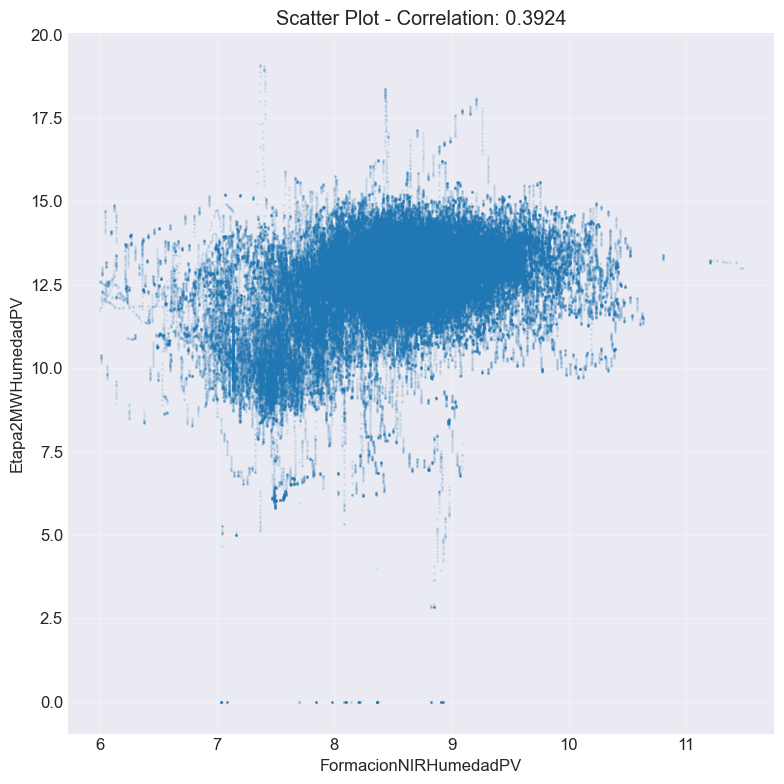

In [6]:
# Correlation analysis
corr_matrix = df_resampled[target_cols].corr()
print('Correlation matrix:')
print(corr_matrix)

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_resampled['FormacionNIRHumedadPV'], 
           df_resampled['Etapa2MWHumedadPV'], 
           alpha=0.1, s=1)
ax.set_xlabel('FormacionNIRHumedadPV')
ax.set_ylabel('Etapa2MWHumedadPV')
ax.set_title(f'Scatter Plot - Correlation: {corr_matrix.iloc[0,1]:.4f}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

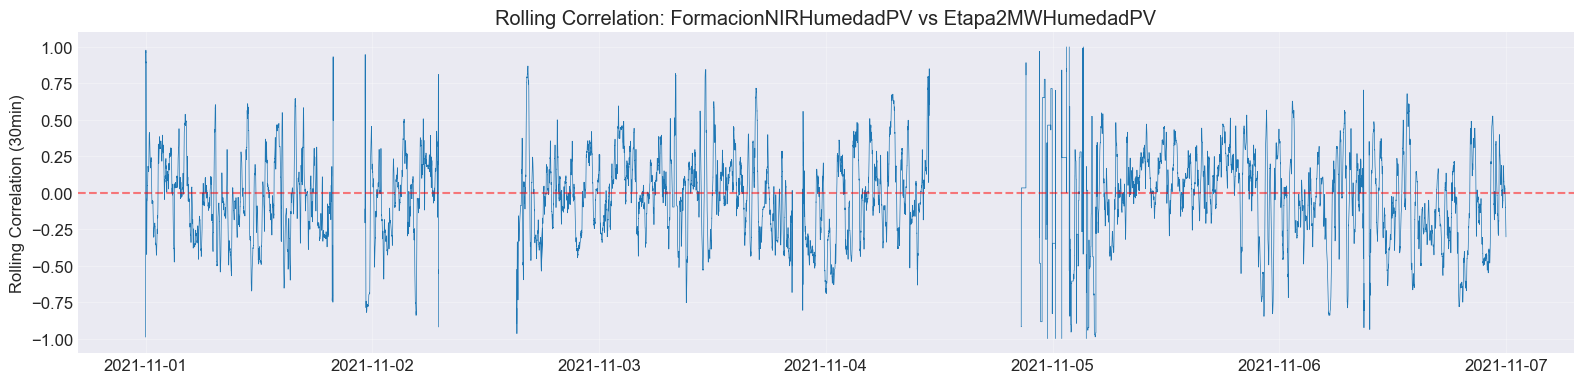

In [7]:
# Rolling correlation
window = '30min'
rolling_corr = df_resampled['FormacionNIRHumedadPV'].rolling(window).corr(df_resampled['Etapa2MWHumedadPV'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(rolling_corr.index, rolling_corr.values, linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel('Rolling Correlation (30min)')
ax.set_title('Rolling Correlation: FormacionNIRHumedadPV vs Etapa2MWHumedadPV')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Max cross-correlation: 0.6071 at lag: 472 samples (472 seconds)


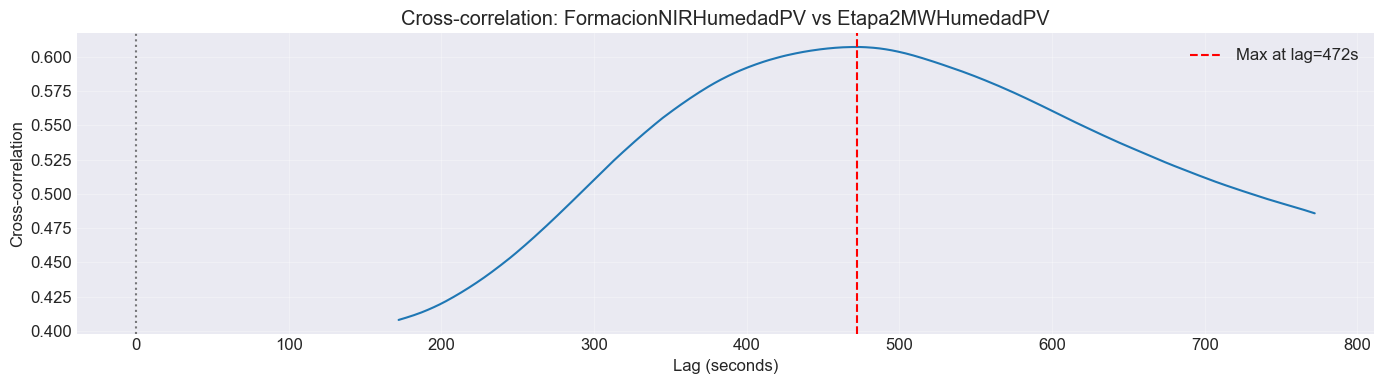

In [8]:
# Cross-correlation to find lag
from scipy.signal import correlate

# Use resampled data, drop NaN
x = df_resampled['FormacionNIRHumedadPV'].dropna().values
y = df_resampled['Etapa2MWHumedadPV'].dropna().values

# Align lengths
min_len = min(len(x), len(y))
x = x[:min_len]
y = y[:min_len]

# Normalize
x_norm = (x - x.mean()) / x.std()
y_norm = (y - y.mean()) / y.std()

# Cross-correlation
corr = correlate(x_norm, y_norm, mode='full')
lags = np.arange(-len(x) + 1, len(x))

# Find peak
max_idx = np.argmax(corr)
max_lag = lags[max_idx]
max_corr = corr[max_idx] / len(x)

print(f'Max cross-correlation: {max_corr:.4f} at lag: {max_lag} samples ({max_lag} seconds)')

# Plot around peak
window = 300  # seconds
mask = (lags >= max_lag - window) & (lags <= max_lag + window)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lags[mask], corr[mask] / len(x))
ax.axvline(x=max_lag, color='r', linestyle='--', label=f'Max at lag={max_lag}s')
ax.axvline(x=0, color='k', linestyle=':', alpha=0.5)
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Cross-correlation')
ax.set_title('Cross-correlation: FormacionNIRHumedadPV vs Etapa2MWHumedadPV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Correlation after alignment (lag=472s): 0.3351
Original correlation: 0.3924


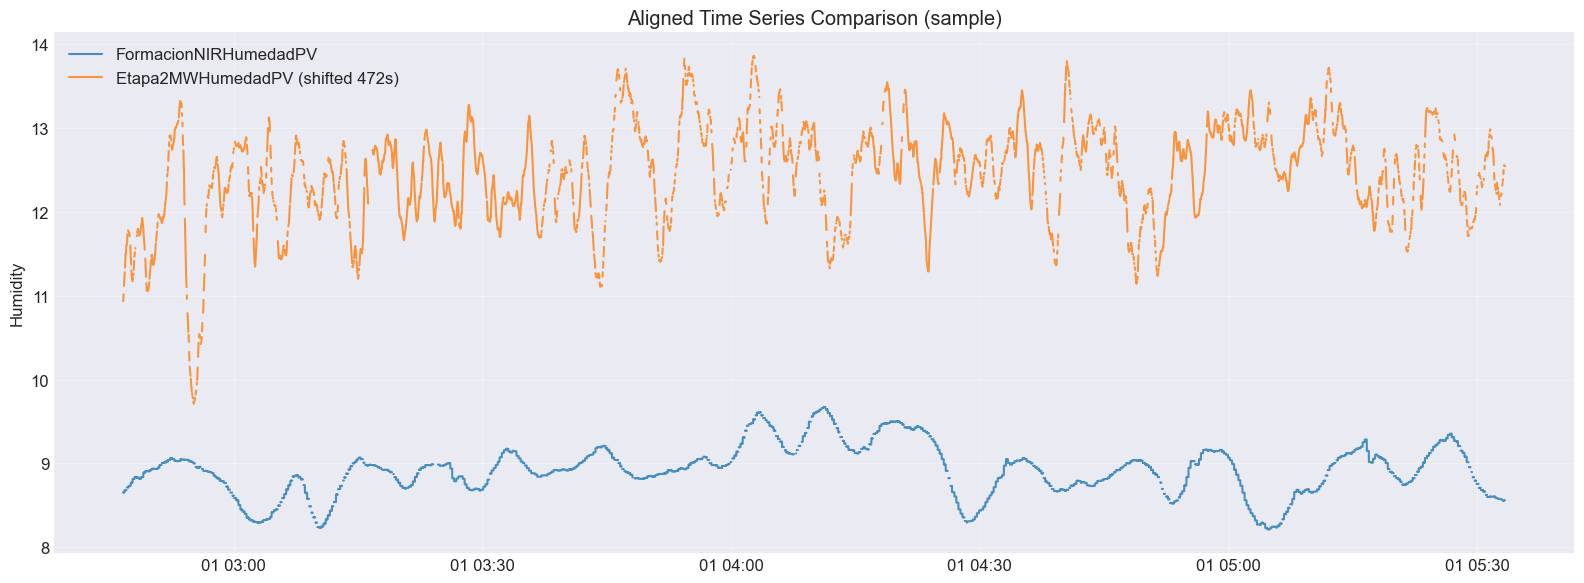

In [9]:
# Shift and align based on cross-correlation
lag_seconds = max_lag

df_aligned = df_resampled.copy()
df_aligned['Etapa2MWHumedadPV_shifted'] = df_aligned['Etapa2MWHumedadPV'].shift(-lag_seconds)

# Correlation after alignment
aligned_corr = df_aligned['FormacionNIRHumedadPV'].corr(df_aligned['Etapa2MWHumedadPV_shifted'])
print(f'Correlation after alignment (lag={lag_seconds}s): {aligned_corr:.4f}')
print(f'Original correlation: {corr_matrix.iloc[0,1]:.4f}')

# Plot aligned series (sample)
sample = df_aligned.iloc[10000:20000]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(sample.index, sample['FormacionNIRHumedadPV'], label='FormacionNIRHumedadPV', alpha=0.8)
ax.plot(sample.index, sample['Etapa2MWHumedadPV_shifted'], label=f'Etapa2MWHumedadPV (shifted {lag_seconds}s)', alpha=0.8)
ax.set_ylabel('Humidity')
ax.set_title('Aligned Time Series Comparison (sample)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Statistical summary by day
daily_stats = df_resampled[target_cols].resample('D').agg(['mean', 'std', 'min', 'max', 'count'])
print(daily_stats)

           FormacionNIRHumedadPV                                        \
                            mean       std       min        max  count   
fecha                                                                    
2021-11-01              8.861513  0.560342  6.356623  11.475540  58428   
2021-11-02              8.662764  0.530734  6.095007  10.216830  44763   
2021-11-03              8.177226  0.652462  6.000023  10.354740  59810   
2021-11-04              8.177609  0.631061  6.232606   9.633470  30711   
2021-11-05              8.385318  0.484788  6.001289  10.426820  58475   
2021-11-06              8.669740  0.778381  6.014682  10.631700  66642   
2021-11-07              9.419346       NaN  9.419346   9.419346      1   

           Etapa2MWHumedadPV                                        
                        mean       std        min       max  count  
fecha                                                               
2021-11-01         12.623707  1.121514   0.000000  1

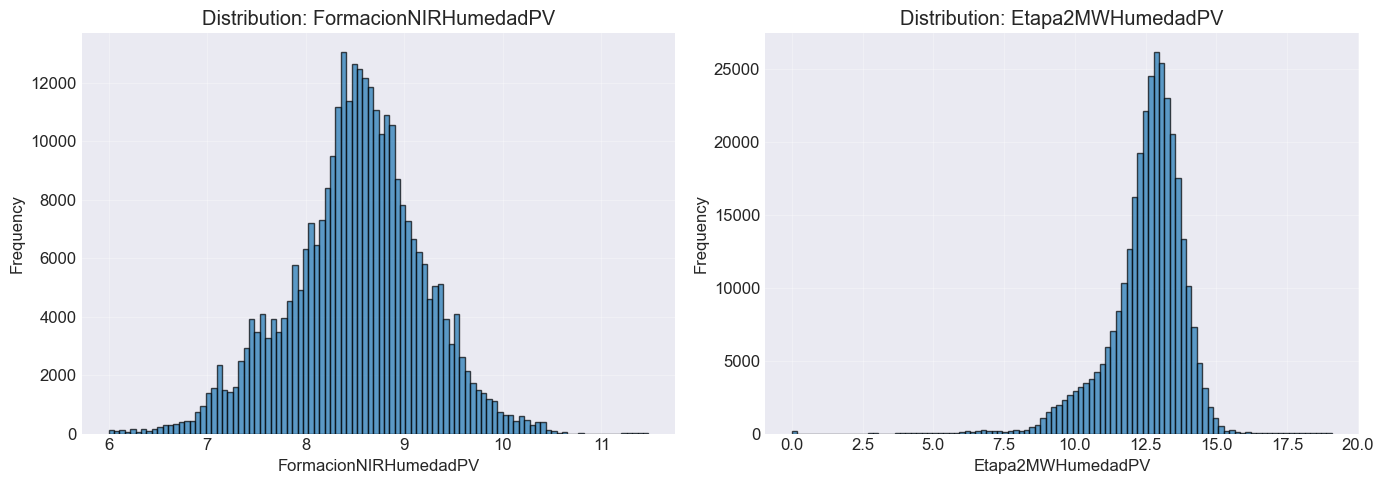

In [11]:
# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(target_cols):
    ax = axes[i]
    df_resampled[col].dropna().hist(bins=100, ax=ax, alpha=0.7, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution: {col}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Save cleaned and aligned data
output_path = Path('../data/synch_analysis_clean.parquet')
df_aligned.to_parquet(output_path)
print(f'Saved to {output_path}')
print(f'Shape: {df_aligned.shape}')
print(f'Columns: {df_aligned.columns.tolist()}')

Saved to data/synch_analysis_clean.parquet
Shape: (518400, 23)
Columns: ['DiscosVida', 'DiscosDistancia', 'SiloFibraVelocidadPV', 'SiloRechazosVelocidadPV', 'FormadoraVelocidadPV', 'ScalperPosPV', 'ScalperReservaMediaPV', 'FormacionVelocidad', 'ColaSecaMaderaSecaPV', 'ParafinaSecaMaderaSecaPV', 'FincatSecaMaderaSecaPV', 'IgnifuganteSecaMaderaSecaPV', 'Etapa2MWHumedadPV', 'Etapa2MWHumedadSP', 'FormacionNIRHumedadPV', 'FormacionNIRResina', 'PreprensaEntPosPV', 'PreprensaEntPresionPV', 'PreprensaSalPosPV', 'PreprensaSalPresionPV', 'PreprensaPrecompresorPosPV', 'BasculaMantaPesoPV', 'Etapa2MWHumedadPV_shifted']
